<a href="https://colab.research.google.com/github/Chaospossum/cv-robustness-thesis/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Robustness Analysis

Run this after all 50 experiments are complete.  
Reads results from Google Drive and produces summary tables, statistical tests, and plots.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/capstone_robustness'
OUT_DIR = '/content/drive/MyDrive/capstone_robustness/analysis'

import os
os.makedirs(OUT_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
!pip install statsmodels seaborn --quiet

In [ ]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load all results
csvs = glob.glob(os.path.join(DRIVE_DIR, '**', '*_robustness.csv'), recursive=True)
print(f'Found {len(csvs)} CSV files')
df = pd.concat([pd.read_csv(f) for f in csvs], ignore_index=True)
df = df.drop_duplicates(
    subset=['model', 'strategy', 'deg_type_trained', 'seed', 'eval_degradation', 'eval_severity'],
    keep='last'
)
print(f'Total rows: {len(df)}')
print(f'Strategies: {df["strategy"].unique()}')
print(f'Models: {df["model"].unique()}')
print(f'Seeds per group:')
print(df.groupby(['model', 'strategy', 'deg_type_trained'])['seed'].nunique())

Found 12 CSV files
Total rows: 1140
Strategies: ['baseline' 'mixed' 'single' 'curriculum']
Models: ['resnet18' 'mobilenetv2']
Seeds per group:
model        strategy    deg_type_trained
mobilenetv2  baseline    none                5
             curriculum  gaussian_blur       5
                         gaussian_noise      5
             mixed       none                5
             single      gaussian_blur       5
                         gaussian_noise      5
resnet18     baseline    none                5
             curriculum  gaussian_blur       5
                         gaussian_noise      5
             mixed       none                5
             single      gaussian_blur       5
                         gaussian_noise      5
Name: seed, dtype: int64


## Summary Table

In [ ]:
# Mean ± std across seeds
summary = df.groupby(
    ['model', 'strategy', 'deg_type_trained', 'eval_degradation', 'eval_severity']
)['accuracy'].agg(['mean', 'std', 'count']).reset_index()
summary['formatted'] = summary.apply(lambda r: f"{r['mean']:.2f} ± {r['std']:.2f}", axis=1)
summary.to_csv(os.path.join(OUT_DIR, 'summary_table.csv'), index=False)

# Show clean accuracies
clean = summary[summary['eval_degradation'] == 'clean'][['model', 'strategy', 'deg_type_trained', 'formatted']]
print('Clean Accuracies:')
display(clean)

Clean Accuracies:


,model,strategy,deg_type_trained,formatted
0,mobilenetv2,baseline,none,89.18 ± 0.07
19,mobilenetv2,curriculum,gaussian_blur,11.86 ± 1.59
38,mobilenetv2,curriculum,gaussian_noise,79.49 ± 1.03
57,mobilenetv2,mixed,none,85.90 ± 0.11
76,mobilenetv2,single,gaussian_blur,77.98 ± 0.61
95,mobilenetv2,single,gaussian_noise,87.00 ± 0.16
114,resnet18,baseline,none,95.09 ± 0.17
133,resnet18,curriculum,gaussian_blur,12.77 ± 2.01
152,resnet18,curriculum,gaussian_noise,89.61 ± 0.29
171,resnet18,mixed,none,92.09 ± 0.09


## Mean Robustness (avg across all 18 degraded conditions)

In [ ]:
degraded = df[df['eval_degradation'] != 'clean']
rob = degraded.groupby(['model', 'strategy', 'deg_type_trained', 'seed'])['accuracy'].mean().reset_index()
rob.columns = ['model', 'strategy', 'deg_type_trained', 'seed', 'mean_robustness']

rob_summary = rob.groupby(['model', 'strategy', 'deg_type_trained'])['mean_robustness'].agg(['mean', 'std']).reset_index()
rob_summary['formatted'] = rob_summary.apply(lambda r: f"{r['mean']:.2f} ± {r['std']:.2f}", axis=1)
print('Mean Robustness:')
display(rob_summary[['model', 'strategy', 'deg_type_trained', 'formatted']])

Mean Robustness:


,model,strategy,deg_type_trained,formatted
0,mobilenetv2,baseline,none,58.80 ± 1.19
1,mobilenetv2,curriculum,gaussian_blur,17.68 ± 1.91
2,mobilenetv2,curriculum,gaussian_noise,55.97 ± 1.52
3,mobilenetv2,mixed,none,81.36 ± 0.10
4,mobilenetv2,single,gaussian_blur,70.44 ± 0.32
5,mobilenetv2,single,gaussian_noise,69.16 ± 0.69
6,resnet18,baseline,none,65.59 ± 0.78
7,resnet18,curriculum,gaussian_blur,18.98 ± 1.53
8,resnet18,curriculum,gaussian_noise,66.90 ± 0.57
9,resnet18,mixed,none,89.30 ± 0.06


## Statistical Tests (paired t-tests, Bonferroni corrected)

In [ ]:
BONFERRONI_K = 7  # clean + 6 degradation types
ADJUSTED_ALPHA = 0.05 / BONFERRONI_K

def run_paired_tests(df, base_strat, aug_strat, aug_deg='none'):
    results = []
    for model_name in df['model'].unique():
        base = df[(df['model'] == model_name) & (df['strategy'] == base_strat)]
        aug = df[(df['model'] == model_name) & (df['strategy'] == aug_strat) & (df['deg_type_trained'] == aug_deg)]
        if base.empty or aug.empty:
            continue

        conditions = ['clean'] + [d for d in df['eval_degradation'].unique() if d != 'clean']
        for cond in conditions:
            b_scores = base[base['eval_degradation'] == cond].groupby('seed')['accuracy'].mean()
            a_scores = aug[aug['eval_degradation'] == cond].groupby('seed')['accuracy'].mean()
            common = sorted(set(b_scores.index) & set(a_scores.index))
            if len(common) < 2:
                continue
            b = b_scores.loc[common].values
            a = a_scores.loc[common].values
            diff = a - b
            t, p = stats.ttest_rel(a, b)
            d = diff.mean() / diff.std() if diff.std() > 0 else 0
            results.append({
                'model': model_name, 'comparison': f'{aug_strat}({aug_deg}) vs baseline',
                'condition': cond, 'base_mean': b.mean(), 'aug_mean': a.mean(),
                'diff': diff.mean(), 't': t, 'p': p, 'cohens_d': d,
                'sig': '*' if p < ADJUSTED_ALPHA else ''
            })
    return pd.DataFrame(results)

all_tests = []
# Mixed vs baseline
all_tests.append(run_paired_tests(df, 'baseline', 'mixed', 'none'))
# Single vs baseline
for deg in ['gaussian_blur', 'gaussian_noise']:
    all_tests.append(run_paired_tests(df, 'baseline', 'single', deg))
# Curriculum vs baseline
for deg in ['gaussian_blur', 'gaussian_noise']:
    all_tests.append(run_paired_tests(df, 'baseline', 'curriculum', deg))

tests_df = pd.concat(all_tests, ignore_index=True)
tests_df.to_csv(os.path.join(OUT_DIR, 'statistical_tests.csv'), index=False)

print(f'Adjusted alpha = {ADJUSTED_ALPHA:.4f}')
print(f'\nSignificant results:')
display(tests_df[tests_df['sig'] == '*'][['model', 'comparison', 'condition', 'diff', 'cohens_d', 'p']])

Adjusted alpha = 0.0071

Significant results:


,model,comparison,condition,diff,cohens_d,p
0,resnet18,mixed(none) vs baseline,clean,-2.998000,-17.822520,3.697256e-06
1,resnet18,mixed(none) vs baseline,gaussian_noise,28.498000,36.662044,2.073129e-07
2,resnet18,mixed(none) vs baseline,gaussian_blur,59.609333,39.714562,1.505821e-07
3,resnet18,mixed(none) vs baseline,motion_blur,30.258667,18.884285,2.934960e-06
4,resnet18,mixed(none) vs baseline,jpeg,24.348667,20.159491,2.261175e-06
...,...,...,...,...,...,...
64,mobilenetv2,curriculum(gaussian_noise) vs baseline,gaussian_noise,32.524667,10.573130,2.956445e-05
66,mobilenetv2,curriculum(gaussian_noise) vs baseline,motion_blur,-7.270000,-2.861200,4.615484e-03
67,mobilenetv2,curriculum(gaussian_noise) vs baseline,jpeg,9.552000,4.672566,7.300676e-04
68,mobilenetv2,curriculum(gaussian_noise) vs baseline,contrast,-30.546667,-14.187261,9.180142e-06


## Tradeoff Plot

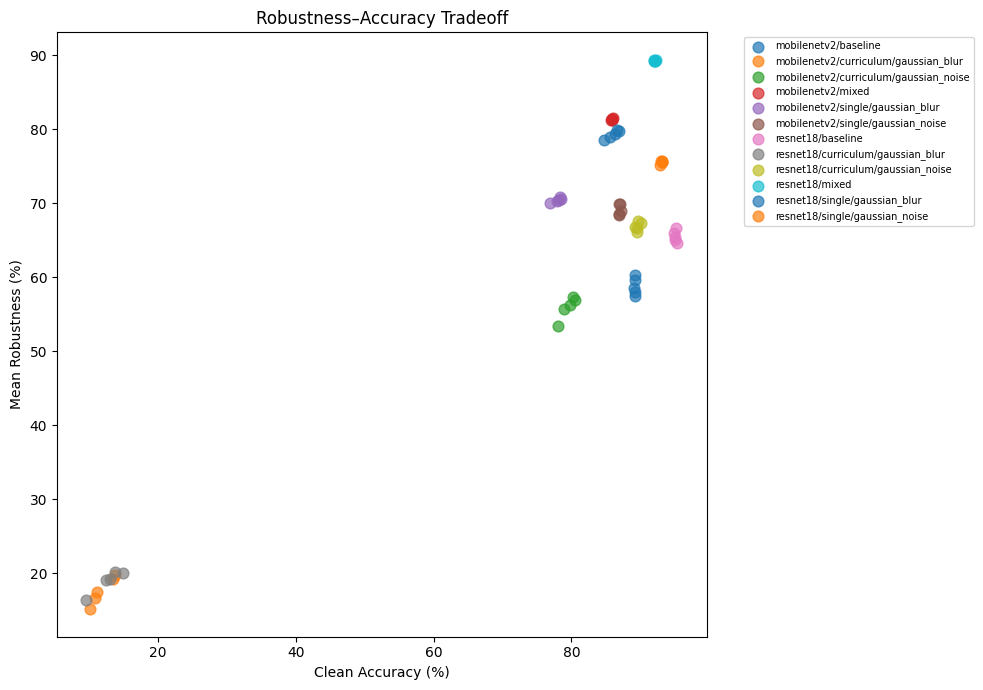

In [ ]:
clean_df = df[df['eval_degradation'] == 'clean'][['model', 'strategy', 'deg_type_trained', 'seed', 'accuracy']]
clean_df = clean_df.rename(columns={'accuracy': 'clean_acc'})
merged = clean_df.merge(rob, on=['model', 'strategy', 'deg_type_trained', 'seed'])

merged['label'] = merged.apply(
    lambda r: f"{r['model']}/{r['strategy']}" + (f"/{r['deg_type_trained']}" if r['deg_type_trained'] != 'none' else ''),
    axis=1
)

fig, ax = plt.subplots(figsize=(10, 7))
for label in sorted(merged['label'].unique()):
    sub = merged[merged['label'] == label]
    ax.scatter(sub['clean_acc'], sub['mean_robustness'], label=label, alpha=0.7, s=60)

ax.set_xlabel('Clean Accuracy (%)')
ax.set_ylabel('Mean Robustness (%)')
ax.set_title('Robustness–Accuracy Tradeoff')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'tradeoff_scatter.png'), dpi=150)
plt.show()

## Per-Degradation Bar Charts

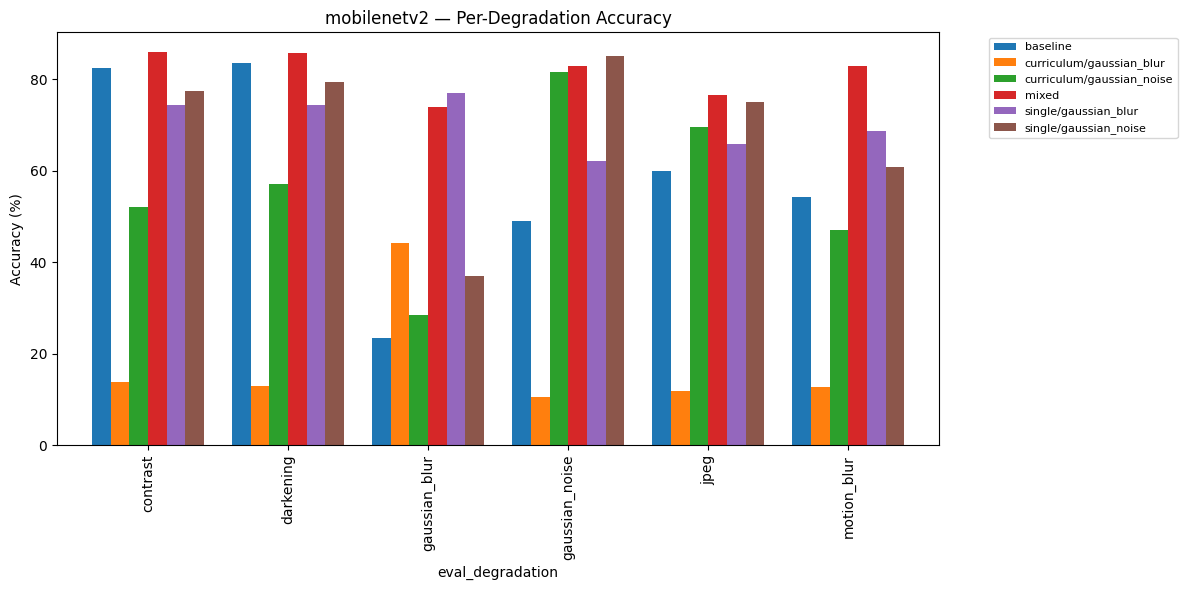

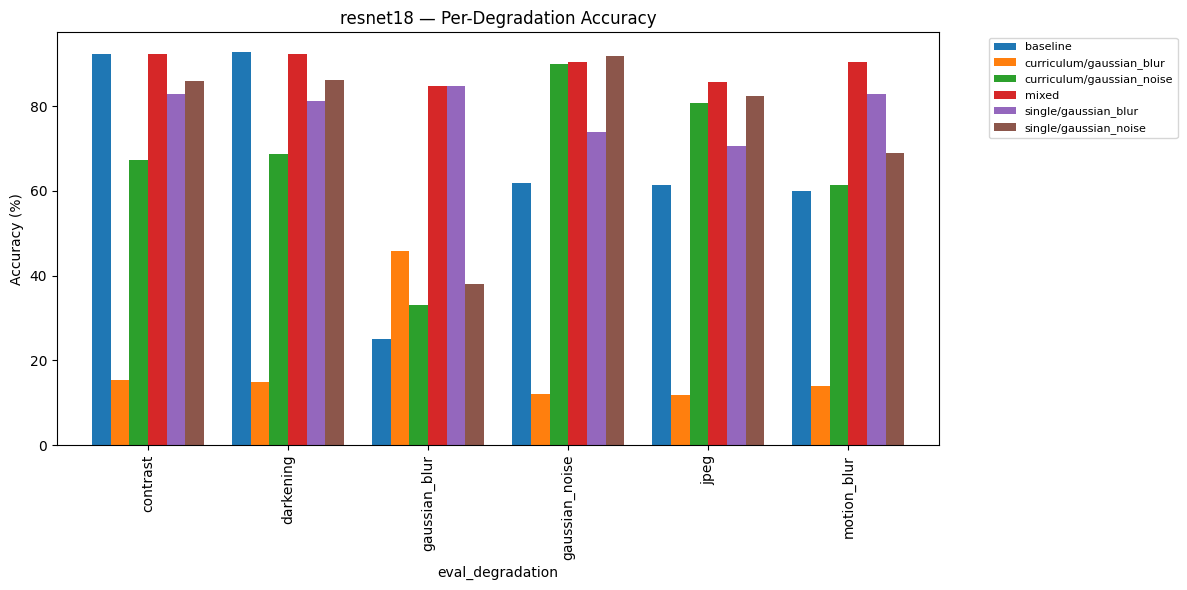

In [ ]:
agg = degraded.groupby(['model', 'strategy', 'deg_type_trained', 'eval_degradation'])['accuracy'].mean().reset_index()
agg['label'] = agg.apply(
    lambda r: f"{r['strategy']}" + (f"/{r['deg_type_trained']}" if r['deg_type_trained'] != 'none' else ''),
    axis=1
)

for model_name in agg['model'].unique():
    sub = agg[agg['model'] == model_name]
    fig, ax = plt.subplots(figsize=(12, 6))
    pivot = sub.pivot_table(index='eval_degradation', columns='label', values='accuracy')
    pivot.plot(kind='bar', ax=ax, width=0.8)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'{model_name} — Per-Degradation Accuracy')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'{model_name}_degradation_bars.png'), dpi=150)
    plt.show()

## Radar Plots

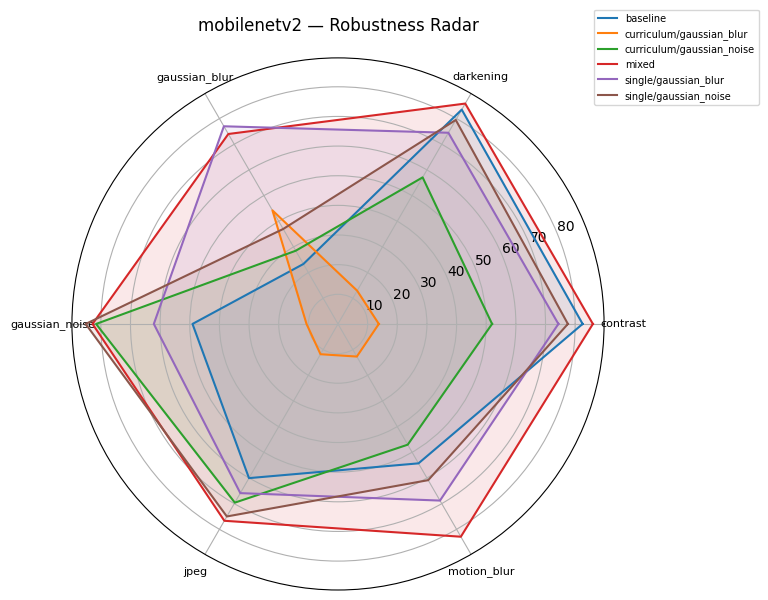

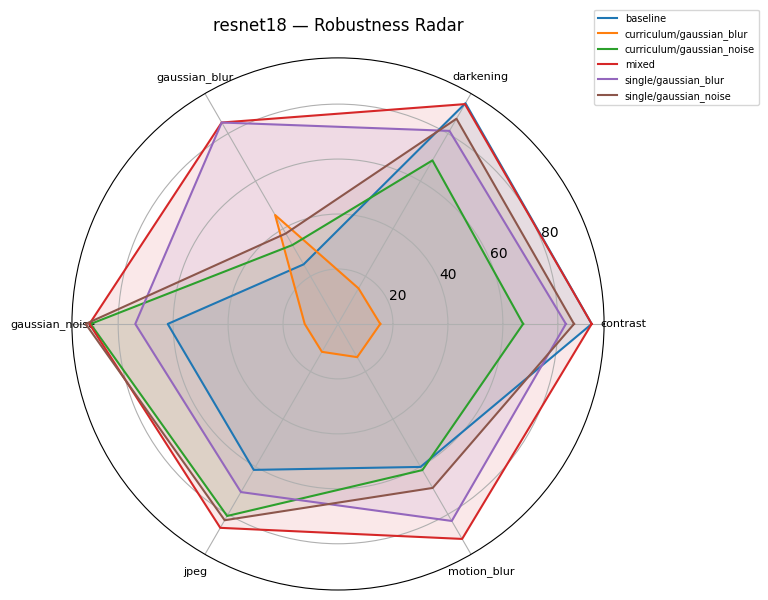

In [ ]:
deg_types = sorted(agg['eval_degradation'].unique())
n = len(deg_types)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]

for model_name in agg['model'].unique():
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    sub = agg[agg['model'] == model_name]

    for label in sub['label'].unique():
        grp = sub[sub['label'] == label]
        values = [grp[grp['eval_degradation'] == dt]['accuracy'].values[0] if len(grp[grp['eval_degradation'] == dt]) > 0 else 0 for dt in deg_types]
        values += values[:1]
        ax.plot(angles, values, label=label, linewidth=1.5)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(deg_types, size=8)
    ax.set_title(f'{model_name} — Robustness Radar', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=7)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'{model_name}_radar.png'), dpi=150)
    plt.show()